In [1]:
# Personal Finance Manager using Streamlit, SQLAlchemy, and PDF parsing

import streamlit as st
from sqlalchemy import create_engine, Column, Integer, String, Float, Date, Text
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
import pandas as pd
from datetime import datetime
# import fitz  # PyMuPDF
import pdfplumber
import io
import os
# import os
import re

In [ ]:

# --- Database Setup ---
Base = declarative_base()

class Spending(Base):
    __tablename__ = 'spendings'
    id = Column(Integer, primary_key=True)
    date = Column(Date)
    amount = Column(Float)
    category = Column(String(50))
    description = Column(Text)

engine = create_engine('sqlite:///finance.db')
Base.metadata.create_all(engine)
Session = sessionmaker(bind=engine)
session = Session()

# --- Helper Functions ---
def add_spending(date, amount, category, description):
    spending = Spending(date=date, amount=amount, category=category, description=description)
    session.add(spending)
    session.commit()

def get_all_spendings():
    return session.query(Spending).all()

def parse_pdf(file):
    lines = []
    with pdfplumber.open(file) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                lines += text.split("\n")
    return lines

def auto_categorize(desc):
    if "coffee" in desc.lower():
        return "Food & Beverage"
    elif "uber" in desc.lower():
        return "Transport"
    elif "shopee" in desc.lower():
        return "Shopping"
    else:
        return "Others"


if __name__=="__main__":
    # --- Streamlit App ---
    st.title("💼 Personal Finance Management")

    st.header("Add Daily Spending")
    date = st.date_input("Date", datetime.today())
    amount = st.number_input("Amount", min_value=0.0, step=0.01)
    description = st.text_input("Description")
    category = st.text_input("Category (optional)")

    if st.button("Add Spending"):
        final_cat = category if category else auto_categorize(description)
        add_spending(date, amount, final_cat, description)
        st.success("Spending added successfully!")

    st.header("Upload PDF Statement")
    pdf_file = st.file_uploader("Upload your credit card statement (PDF)", type="pdf")
    if pdf_file:
        lines = parse_pdf(pdf_file)
        for line in lines:
            parts = line.strip().split()
            try:
                # Simple rule: date amount description
                if len(parts) >= 3 and parts[0].count("/") == 2:
                    parsed_date = datetime.strptime(parts[0], "%d/%m/%Y").date()
                    parsed_amount = float(parts[1].replace(',', ''))
                    parsed_desc = " ".join(parts[2:])
                    parsed_cat = auto_categorize(parsed_desc)
                    add_spending(parsed_date, parsed_amount, parsed_cat, parsed_desc)
            except:
                continue
        st.success("PDF processed successfully!")

    st.header("Spending Summary")
    spendings = get_all_spendings()
    df = pd.DataFrame([(s.date, s.amount, s.category, s.description) for s in spendings],
                    columns=["Date", "Amount", "Category", "Description"])
    st.dataframe(df.sort_values(by="Date", ascending=False))

    st.subheader("Category Summary")
    if not df.empty:
        summary = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
        st.bar_chart(summary)


C:\Users\nghia.n\AppData\Local\Temp\ipykernel_52716\1462378648.py:2: MovedIn20Warning: Deprecated API features detected! These feature(s) are not compatible with SQLAlchemy 2.0. To prevent incompatible upgrades prior to updating applications, ensure requirements files are pinned to "sqlalchemy<2.0". Set environment variable SQLALCHEMY_WARN_20=1 to show all deprecation warnings.  Set environment variable SQLALCHEMY_SILENCE_UBER_WARNING=1 to silence this message. (Background on SQLAlchemy 2.0 at: https://sqlalche.me/e/b8d9)
  Base = declarative_base()


In [5]:
pdf_path = r"C:\Users\nghia.n\OneDrive - COLLECTIUS SYSTEMS PTE. LTD\Documents\1.Personal\1.Learning\1. Practice\PersonaFinanceSystem\raw_data"

list_statements = os.listdir(r"C:\Users\nghia.n\OneDrive - COLLECTIUS SYSTEMS PTE. LTD\Documents\1.Personal\1.Learning\1. Practice\PersonaFinanceSystem\raw_data")

In [38]:
df = pd.DataFrame()
lines = []
for file in list_statements:

    # pdf_path = r"C:\Users\nghia.n\OneDrive - COLLECTIUS SYSTEMS PTE. LTD\Documents\1.Personal\1.Learning\1. Practice\PersonaFinanceSystem\raw_data\NGUYEN DUY NGHIA_814866664826_202502.pdf"

    # lines = parse_pdf(pdf_file, pass)


    
    with pdfplumber.open(os.path.join(pdf_path, file) , password = '551459') as pdf:
        for i in range(len(pdf.pages)):
            page = pdf.pages[i]
            text = page.extract_text()
            try:
                if text:
                    if "CLOSING BALANCE" in text:
                        tmp_lines = text.split("\n")

                        closing_idx = [idx for idx, line in enumerate(tmp_lines) if "CLOSING BALANCE" in line]
                        # Find the index of "CLOSING BALANCE" and slice the list
                        # closing_index = tmp_lines.index("CLOSING BALANCE")
                        lines += tmp_lines[:closing_idx[0] + 1]

                        print(f"done with page {i + 1}")
                        break
                    else:
                        lines += text.split("\n")
                        print(f"done with page {i + 1}")
            except:
                lines += text.split("\n")
                print(f"done with page {i + 1}")

                continue


correct_lines = []


# Extract components
rows = []
for line in lines:
    match = re.match(r'^(\d{2}/\d{2}/\d{4}) (\d{2}/\d{2}/\d{4}) (.+) (\d{1,3}(?:,\d{3})*)$', line)
    if match:
        rows.append({
            'issued_date': match.group(1),
            'effective_date': match.group(2),
            'description': match.group(3).strip(),
            'amount': match.group(4).replace(',', '')  # remove commas
        })

# Create DataFrame
df = pd.DataFrame(rows)

# Convert columns
df['issued_date'] = pd.to_datetime(df['issued_date'], format='%d/%m/%Y')
df['effective_date'] = pd.to_datetime(df['effective_date'], format='%d/%m/%Y')
df['amount'] = pd.to_numeric(df['amount'])

# Final result
df.head()

done with page 1
done with page 2
done with page 1
done with page 2
done with page 1
done with page 2
done with page 1
done with page 2
done with page 1
done with page 2
done with page 1
done with page 2


,issued_date,effective_date,description,amount
0,2025-01-23,2025-01-23,Payment To Client Contract THANH TOAN NO THE T...,25089438
1,2025-02-15,2025-02-15,TRA GOP,798333
2,2025-01-14,2025-01-16,Retail VNM HO CHI MINH CTCP Y DUOC VIETLIFE,2000000
3,2025-01-14,2025-01-16,Retail VNM HO CHI MINH MPGS BEGROUP,42000
4,2025-01-14,2025-01-16,Retail VNM HO CHI MINH MPGS BEGROUP,48000


In [ ]:
pdf_path = r"C:\Users\nghia.n\OneDrive - COLLECTIUS SYSTEMS PTE. LTD\Documents\1.Personal\1.Learning\1. Practice\PersonaFinanceSystem\raw_data"

file = '19771725556011_20250820-16012520926852_Stmt_NGUYEN DUY NGHIA.pdf'
lines = []
16010263
with pdfplumber.open(os.path.join(pdf_path, file) , password = '') as pdf:
    for i in range(len(pdf.pages)):
        page = pdf.pages[i]
        text = page.extract_text()
        try:
            if text:
                if "Số dư cần thanh toán" in text:
                    tmp_lines = text.split("\n")

                    closing_idx = [idx for idx, line in enumerate(tmp_lines) if "Số dư cần thanh toán" in line]
                    # Find the index of "Số dư cần thanh toán" and slice the list
                    # closing_index = tmp_lines.index("Số dư cần thanh toán")
                    lines += tmp_lines[:closing_idx[0] + 1]

                    print(f"done with page {i + 1}")
                    break
                else:
                    lines += text.split("\n")
                    print(f"done with page {i + 1}")
        except:
            lines += text.split("\n")
            print(f"done with page {i + 1}")

            continue

done with page 1


In [39]:
df.to_csv(os.path.join(pdf_path, "parsed_statements.csv"), index=False)

In [41]:
lines = []

with pdfplumber.open(os.path.join(pdf_path, 'NGUYEN DUY NGHIA_814866664826_202507.pdf') , password = '551459') as pdf:
        for i in range(len(pdf.pages)):
            page = pdf.pages[i]
            text = page.extract_text()
            try:
                if text:
                    if "CLOSING BALANCE" in text:
                        tmp_lines = text.split("\n")

                        closing_idx = [idx for idx, line in enumerate(tmp_lines) if "CLOSING BALANCE" in line]
                        # Find the index of "CLOSING BALANCE" and slice the list
                        # closing_index = tmp_lines.index("CLOSING BALANCE")
                        lines += tmp_lines[:closing_idx[0] + 1]

                        print(f"done with page {i + 1}")
                        break
                    else:
                        lines += text.split("\n")
                        print(f"done with page {i + 1}")
            except:
                lines += text.split("\n")
                print(f"done with page {i + 1}")

                continue

done with page 1
done with page 2


In [1]:
import torch
print(torch.cuda.is_available(), torch.cuda.device_count())

False 0


In [14]:
import sqlite3
import pandas as pd
import streamlit as st
from datetime import date

In [ ]:
# conn = sqlite3.connect('finance.db')
# cursor = conn.cursor()
# cursor.execute('''
# CREATE TABLE IF NOT EXISTS transactions (
#     id INTEGER PRIMARY KEY,
#     date TEXT,
#     description TEXT,
#     category TEXT,
#     debit_account TEXT,
#     credit_account TEXT,
#     amount REAL
# )
# ''')
# conn.commit()

In [ ]:
# df = pd.read_csv("raw_data/2025Q3Q4.csv", delimiter="|")
# # df = df.loc[lambda df: df['Amount'] > 0]
# df.tail(10)

,Date,Debit-Account,Credit-Account,Category,Description,Amount
60,7/20/2025,Expense,Cash,parents,NaN,875000
61,7/20/2025,Expense,Cash,food&beverage,NaN,200000
62,7/20/2025,Expense,Cash,food&beverage,withdraw,2000000
63,7/27/2025,Expense,Cash,hobby,lego & minicar,1016000
64,7/31/2025,Cash,Income:Salary,salary,Jul 2025 salary,67753000
65,7/31/2025,Liability:Payable,Cash,credit_payment,Jul 2025 credit payment,41418000
66,8/1/2025,Cash,Equity:Opening Balance,salary,Opening Balance,91021000
67,8/1/2025,Asset:Savings,Cash,investment,1000 HPG; 1000 HSG; 200 STB,50355000
68,8/3/2025,Expense,Cash,transport,Do dau,200000
69,8/3/2025,Expense,Cash,parents,mua sua,1868000


In [ ]:
# df = pd.read_csv("raw_data/2025-Aug.csv", delimiter="|")
# df = df.loc[lambda df: df['Amount'] > 0]

In [19]:
conn.execute('''
            delete from transactions
        ''')
conn.commit()

In [17]:
df = pd.DataFrame(
    {
        "Date": ['9/3/2025', '9/6/2025'],
        "Description": ["tra anh 2", "balance payable"],
        "Category": ["lend", "others"],
        "Debit-Account": ["Liability:Payable", "Cash"],
        "Credit-Account": ["Cash", "Liability:Payable"],
        "Amount": [5000000, 1462933]
    }
)

In [18]:
for index, row in df.iterrows():
    date = row['Date']
    desc = row['Description']
    category = row['Category']
    debit = row['Debit-Account']
    credit = row['Credit-Account']
    amount = row['Amount']

    # Insert into the database

    conn.execute('''
            INSERT INTO transactions (date, description, category, debit_account, credit_account, amount)
            VALUES (?, ?, ?, ?, ?, ?)
        ''', (date, desc, category, debit, credit, amount))
    conn.commit()

In [18]:
from sqlalchemy import inspect
from sqlalchemy import create_engine, Column, Integer, String, Float, Date, Text

engine = create_engine('sqlite:///finance.db')
inspector = inspect(engine)
print(inspector.get_table_names())

# Get column details
columns = inspector.get_columns('transactions')

# # Print schema
for col in columns:
    print(f"{col['name']} - {col['type']} - nullable: {col['nullable']}")


# with engine.connect() as connection:
#     result = connection.execute("SELECT * FROM spendings LIMIT 5")
#     for row in result:
#         print(row)

['spendings', 'transactions']
id - INTEGER - nullable: True
date - TEXT - nullable: True
description - TEXT - nullable: True
category - TEXT - nullable: True
debit_account - TEXT - nullable: True
credit_account - TEXT - nullable: True
amount - REAL - nullable: True


In [19]:
def get_ledger(conn):
    df = pd.read_sql_query("SELECT * FROM transactions", conn)
    return df

def get_account_balance(conn):
    df = get_ledger(conn)
    debit = df.groupby('debit_account')['amount'].sum()
    credit = df.groupby('credit_account')['amount'].sum()
    balance = (debit - credit).fillna(0).add(-credit, fill_value=0).to_frame('balance')
    return balance.reset_index().rename(columns={'index': 'account'})

In [20]:
balance_df = get_account_balance(conn)


In [21]:
df = get_ledger(conn)
debit = df.groupby('debit_account')['amount'].sum()
credit = df.groupby('credit_account')['amount'].sum()

account_names = ['Asset:Receivable', 'Asset:Savings', 'Cash', 'Equity:Opening Balance',
       'Expense', 'Income:Salary', 'Liability:Payable']
for key in account_names:
    if key not in debit.index:
        debit[key] = 0
    if key not in credit.index:
        credit[key] = 0

In [22]:
debit.sort_index(inplace=True)
credit.sort_index(inplace=True)

In [23]:
balance = (debit - credit).fillna(0).to_frame('balance')

In [24]:
balance

,balance
debit_account,
Asset:Receivable,0.0
Asset:Savings,50355000.0
Cash,11162000.0
Equity:Opening Balance,-91021000.0
Expense,140797067.0
Income:Salary,-107756000.0
Liability:Payable,-3537067.0


In [14]:
all_accounts = pd.concat([debit, credit], axis=1, keys=["debit", "credit"]).fillna(0)
all_accounts["balance"] = all_accounts["debit"] - all_accounts["credit"]

In [15]:
all_accounts

,debit,credit,balance
Asset:Receivable,12293000.0,12293000.0,0.0
Asset:Savings,50355000.0,0.0,50355000.0
Cash,216070000.0,204908000.0,11162000.0
Equity:Opening Balance,0.0,91021000.0,-91021000.0
Expense,140797067.0,0.0,140797067.0
Income:Salary,0.0,107756000.0,-107756000.0
Liability:Payable,46920000.0,50457067.0,-3537067.0


In [62]:
credit

credit_account
Asset:Receivable             17293.0
Asset:Savings                    0.0
Cash                        202840.0
Equity:Opening Balance       65355.0
Expense                          0.0
Income:Salary               107756.0
Liability:Payable         45462067.0
Name: amount, dtype: float64

In [27]:
def get_account_balance(conn):
    df = get_ledger(conn)
    debit = df.groupby('debit_account')['amount'].sum()
    credit = df.groupby('credit_account')['amount'].sum()

    account_names = ['Asset:Receivable', 'Asset:Savings', 'Cash', 'Equity:Opening Balance',
       'Expense', 'Income:Salary', 'Liability:Payable']
    for key in account_names:
        if key not in debit.index:
            debit[key] = 0
        if key not in credit.index:
            credit[key] = 0

    debit.sort_index(inplace=True)
    credit.sort_index(inplace=True)
    balance = (debit - credit).fillna(0).to_frame('balance')
    return balance.reset_index().rename(columns={'index': 'account'})


In [29]:
balance = get_account_balance(conn)
balance.rename(columns={'debit_account': 'account'}, inplace=True)

In [5]:
import sqlite3
import pandas as pd
import streamlit as st
from datetime import date

def init_db():
    conn = sqlite3.connect('finance.db')
    cursor = conn.cursor()
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS transactions (
        id INTEGER PRIMARY KEY,
        date TEXT,
        description TEXT,
        category TEXT,
        debit_account TEXT,
        credit_account TEXT,
        amount REAL
    )
    ''')
    conn.commit()
    return conn

In [31]:
cursor = conn.cursor()
cursor.execute('''
drop table if exists transactions
''')
conn.commit()

In [32]:
conn = sqlite3.connect('finance.db')
cursor = conn.cursor()
cursor.execute('''
CREATE TABLE IF NOT EXISTS transactions (
    id INTEGER PRIMARY KEY,
    date DATE,
    description TEXT,
    category TEXT,
    debit_account TEXT,
    credit_account TEXT,
    amount REAL
)
''')
conn.commit()

In [23]:
conn = init_db()
df = pd.read_sql_query("SELECT * FROM transactions", conn)

In [41]:
df["description"] = df["description"].astype(str)
df["category"] = df["category"].astype(str)
df["debit_account"] = df["debit_account"].astype(str)
df["credit_account"] = df["credit_account"].astype(str)


In [49]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")
df["date"] = df["date"].dt.strftime("%Y-%m-%d")


In [50]:
df

,id,date,description,category,debit_account,credit_account,amount
0,1,2025-06-02,Retail VNM HO CHI MINH MPGS BEGROUP,food&beverage,Expense,Liability:Payable,372000
1,2,2025-06-03,Retail VNM shopee.vn Shopee,shopping,Expense,Liability:Payable,558767
2,3,2025-06-03,Retail VNM HO CHI MINH MPGS BEGROUP 9,food&beverage,Expense,Liability:Payable,51000
3,4,2025-06-03,Retail VNM HO CHI MINH MPGS BEGROUP 9,food&beverage,Expense,Liability:Payable,79000
4,5,2025-06-04,Retail VNM shopee.vn Shopee,shopping,Expense,Liability:Payable,3050000
...,...,...,...,...,...,...,...
102,103,2025-09-03,eat w luv,love,Expense,Cash,148000
103,104,2025-09-03,eat w luv,love,Expense,Cash,200000
104,105,2025-09-03,mua dio,hobby,Expense,Cash,100000
105,106,2025-09-03,travel + with team,travel,Expense,Cash,6305000


In [ ]:
# df = pd.read_sql_query("SELECT * FROM transactions", conn)
# df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

# # --- Monthly Expense & Income
# df['month'] = df['date'].dt.to_period('M')

expense_df = df[df['debit_account'].str.startswith("Expense")]
income_df = df[df['credit_account'].str.startswith("Income")]

monthly_expense = expense_df.groupby('month')['amount'].sum().reset_index()
monthly_expense.rename({"amount": "Expense"}, axis=1, inplace=True)
monthly_income = income_df.groupby('month')['amount'].sum().reset_index()
monthly_income.rename({"amount": "Income"}, axis=1, inplace=True)
monthly_summary = pd.concat([monthly_income[["Income"]], monthly_expense], axis=1).fillna(0).reset_index()



In [1]:
65032 - 59815

5217

In [80]:
monthly_summary

,index,Income,month,Expense
0,0,36803000.0,2025-06,110071209
1,1,70953000.0,2025-07,28657858
2,2,35123000.0,2025-08,15438000
3,3,0.0,2025-09,11523000


In [75]:
monthly_expense

,month,Expense
0,2025-06,110071209
1,2025-07,28657858
2,2025-08,15438000
3,2025-09,11523000


In [ ]:
# for index, row in df.iterrows():
#     date = row['date']
#     desc = row['description']
#     category = row['category']
#     debit = row['debit_account']
#     credit = row['credit_account']
#     amount = row['amount']

#     # Insert into the database

#     conn.execute('''
#             INSERT INTO transactions (date, description, category, debit_account, credit_account, amount)
#             VALUES (?, ?, ?, ?, ?, ?)
#         ''', (date, desc, category, debit, credit, amount))
#     conn.commit()

In [ ]:
# df.to_csv("raw_data/2025Q3Q4_v2.csv", index=False)

C:\Users\nghia.n\AppData\Local\Temp\ipykernel_33676\1497041038.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot=pivot_balance.applymap(lambda x: f"{x:,.0f}"),


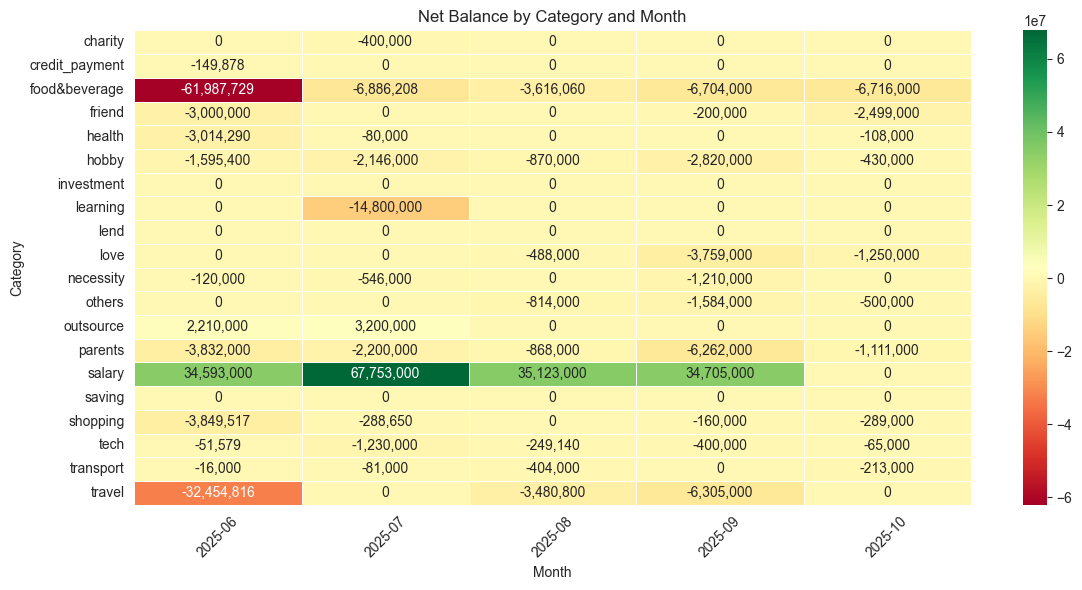

In [1]:
# Re-import libraries after environment reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Load the database
conn = sqlite3.connect("finance.db")
df = pd.read_sql_query("SELECT * FROM transactions", conn)
conn.close()

# Prepare datetime
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)

# Calculate balance per category per month
# Income: credit -> +amount | Expense: debit -> -amount
df['signed_amount'] = df.apply(
    lambda row: row['amount'] if row['credit_account'].startswith('Income') else (
        -row['amount'] if row['debit_account'].startswith('Expense') else 0),
    axis=1
)

# Pivot the result: rows = category, columns = month, values = net balance
pivot_balance = df.pivot_table(
    index='category',
    columns='month',
    values='signed_amount',
    aggfunc='sum',
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_balance,
    annot=pivot_balance.applymap(lambda x: f"{x:,.0f}"),
    fmt='',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar=True
)
plt.title("Net Balance by Category and Month")
plt.xlabel("Month")
plt.ylabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('finance.db')
cursor = conn.cursor()

In [5]:
def get_ledger(conn):
    df = pd.read_sql_query("SELECT * FROM transactions ORDER BY date DESC", conn)
    return df

df = get_ledger(conn)

In [9]:
pd.read_sql_query("SELECT * FROM budgets", conn)['category']

0          Growth & Learning
1                       Food
2        Savings & Investing
3              Debt Payments
4    Personal Care/Lifestyle
5                     Income
6     Family/Love/Dependents
Name: category, dtype: object

In [3]:
sorted(pd.read_sql_query("SELECT * FROM budgets", conn)['category'].unique())

[]

In [1]:
cat_dict = {
                    "Income": ["Salary", "Bonuses", "Outsourcing", "Investment income", "Side hustle revenue"],
                    "Housing": ["Mortgage/rent", "Property taxes", "HOA fees", "Maintenance"],
                    "Food": ["Groceries", "Dining out"],
                    "Growth & Learning": ["Courses", "Books", "Workshops", "Certifications", "Tuition"],
                    "Transportation": ["Car payments", "Gas", "Insurance", "Maintenance", "Public transit fees"],
                    "Utilities": ["Electricity", "Internet", "Phone"],
                    "Savings & Investing" : ["Emergency fund", "Brokerage accounts"],
                    "Debt Payments": ["Credit card debt", "Personal loans", "Bank loans"],
                    "Healthcare": ["Insurance premiums", "Copays", "Prescriptions"],
                    "Personal Care/Lifestyle": ["Clothing", "Grooming", "Entertainment", "Subscriptions"],
                    "Family/Love/Dependents": ["Parental care", "Love", "Childcare", "School fees", "Pet care"],
                    "Protection": ["Life insurance", "Disability insurance", "Estate planning"],
                    "Others": "Other expense"
                    }

In [3]:
list(cat_dict.keys()).index("Others")

12

In [15]:
cursor.execute('''
   CREATE TABLE budgets (
       category TEXT PRIMARY KEY,
       monthly_limit REAL
    )
    ''')
conn.commit()

In [6]:
existing_pairs = df.loc[lambda df: df['subcategory'].notna()][['category']].dropna().drop_duplicates()


In [7]:
existing_pairs

,category
0,Growth & Learning
1,Food
2,Savings & Investing
4,Debt Payments
5,Personal Care/Lifestyle
11,Income
17,Family/Love/Dependents


In [8]:
# Extract distinct (category, subcategory) pairs from transactions

# Load current budgets
# budget_df = pd.read_sql_query("SELECT category, subcategory FROM budgets", conn)

# # Identify missing (cat, subcat) pairs not yet in budget table
# missing = pd.merge(existing_pairs, budget_df, on=['category', 'subcategory'], how='left', indicator=True)
# missing = missing[missing['_merge'] == 'left_only'][['category', 'subcategory']]
# missing['monthly_limit'] = 0

# Insert missing into the budgets table
for _, row in existing_pairs.iterrows():
    conn.execute("""
        INSERT INTO budgets (category, monthly_limit)
        VALUES (?, ?)
    """, (row['category'], 0))
conn.commit()

# st.success("✅ Budgets table initialized with all existing category/subcategory pairs.")


In [2]:
cursor.execute('''
ALTER TABLE transactions ADD COLUMN subcategory TEXT
''')

In [ ]:
dict_category = {
                    "Income": ["Salary", "Bonuses", "Outsourcing", "Investment income", "Side hustle revenue"],
                    "Housing": ["Mortgage/rent", "Property taxes", "HOA fees", "Maintenance"],
                    "Food": ["Groceries", "dining out"],
                    "Transportation": ["Car payments", "Gas", "Insurance", "Maintenance", "Public transit fees"],
                    "Utilities": ["Electricity", "Internet", "Phone"],
                    "Savings & Investing" : ["Emergency fund", "Brokerage accounts"],
                    "Debt Payments": ["Credit card debt", "Personal loans", "Bank loans"],
                    "Healthcare": ["Insurance premiums", "Copays", "Prescriptions"],
                    "Personal Care/Lifestyle": ["Clothing", "Grooming", "Entertainment", "Subscriptions"],
                    "Family/Dependents": ["Childcare", "School fees", "Pet care"],
                    "Protection": ["Life insurance", "Disability insurance", "Estate planning"]
                    }

2025-10-25 14:50:47.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-25 14:50:47.613 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-25 14:50:47.613 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
C:\Users\nghia.n\AppData\Local\Temp\ipykernel_33676\3055732503.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot=all_balances.applymap(lambda x: f"{x:,.0f}"),


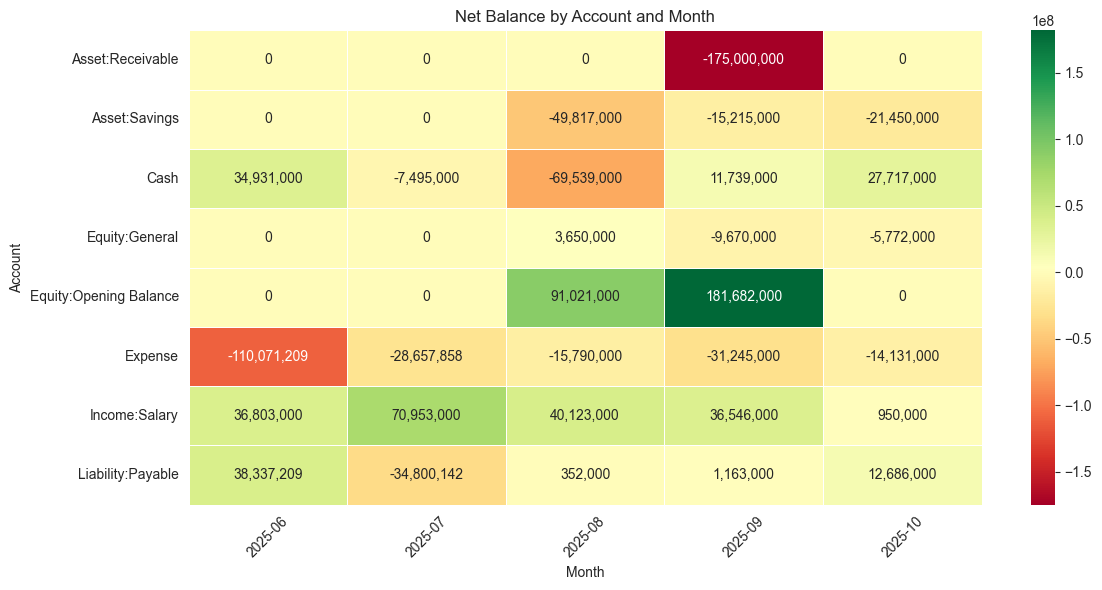

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

st.header("📊 Net Monthly Balance by Account (All Types)")


# Assume `df` already has these columns:
# ['date', 'debit_account', 'credit_account', 'amount']

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)

# Debit: positive
debit_bal = df.groupby(['debit_account', 'month'])['amount'].sum().unstack(fill_value=0)

# Credit: negative
credit_bal = df.groupby(['credit_account', 'month'])['amount'].sum().unstack(fill_value=0) * -1

# Combine: Net balance per account per month
all_balances = debit_bal.add(credit_bal, fill_value=0)

# Clean index
all_balances.index.name = 'account'


fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    all_balances,
    annot=all_balances.applymap(lambda x: f"{x:,.0f}"),
    fmt='',
    cmap="RdYlGn",
    linewidths=0.5,
    cbar=True,
    ax=ax
)
ax.set_title("Net Balance by Account and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Account")
plt.xticks(rotation=45)
plt.tight_layout()

# st.pyplot(fig)
plt.show()